# Assigment I: Profiling Codes

## Exercise I: Profiling the Julia Set Code

## Task 1.1

In order to measure the clock granularity of different timer we use the provided benchmark which we run a 1000 times.

In [ ]:
import time
import timeit
import numpy as np

### time()

In [ ]:
def checktick():
    M = 1000
    timesfound = np.empty(M)
    for i in range(M):
        t1 = time.time()  # get timestamp from timer
        t2 = time.time()  # get timestamp from timer
        while (t2 - t1) < 1e-16:  # if zero then we are below clock granularity, retake timing
            t2 = time.time()  # get timestamp from timer
        t1 = t2  # this is outside the loop
        timesfound[i] = t1  # record the time stamp
    Delta = np.diff(timesfound)  # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta * 1e9


print(checktick(), "ns")

238.4185791015625 ns


### timeit()

In [ ]:
def checktick():
    M = 1000
    timesfound = np.empty(M)
    for i in range(M):
        t1 = timeit.default_timer()  # get timestamp from timer
        t2 = timeit.default_timer()  # get timestamp from timer
        while (t2 - t1) < 1e-16:  # if zero then we are below clock granularity, retake timing
            t2 = timeit.default_timer()  # get timestamp from timer
        t1 = t2  # this is outside the loop
        timesfound[i] = t1  # record the time stamp
    Delta = np.diff(timesfound)  # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta * 1e9


print(checktick(), "ns")

119.99873095192015 ns


### time_ns()

In [ ]:
def checktick():
    M = 1000
    timesfound = np.empty(M, dtype='int')
    for i in range(M):
        t1 = time.time_ns()  # get timestamp from timer
        t2 = time.time_ns()  # get timestamp from timer
        while (t2 - t1) < 1e-16:  # if zero then we are below clock granularity, retake timing
            t2 = time.time_ns()  # get timestamp from timer
        t1 = t2  # this is outside the loop
        timesfound[i] = t1  # record the time stamp
    Delta = np.diff(timesfound)  # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta


print(checktick(), "ns")

150 ns


As can be seen the precision on this machine is much better than the stated 1ms, with `timeit` having the best precision.

## Task 1.2

The decorator is based on the Lecture 1.5, with the added functionality of rerunning the function a certain amount of times.

In [ ]:
import timeit
import JuliaSet
import numpy as np
from functools import wraps


def timerdec(fn):
    @wraps(fn)
    def measure(*args, **kwargs):
        M = 30
        dt = np.empty(M)
        result = None
        for i in range(M):
            t1 = timeit.default_timer()
            result = fn(*args, **kwargs)
            t2 = timeit.default_timer()
            dt[i] = t2 - t1
        print(f"@timedec: {fn.__name__} takes {dt.mean()} +/- {dt.std()} s (Based on {M} runs)\n")
        return result

    return measure

We wrap and test the function separately so they don't interfere with each other. This wrapping is equivalent to putting the `@timerdec` in the source code.

In [ ]:
JuliaSet.calc_pure_python = timerdec(JuliaSet.calc_pure_python)
JuliaSet.calc_pure_python(desired_width=1000, max_iterations=300)

@timedec: calc_pure_python takes 2.9398750937000537 +/- 0.01779296150542568 s (Based on 30 runs)



In [ ]:
JuliaSet.calculate_z_serial_purepython = timerdec(JuliaSet.calculate_z_serial_purepython)
JuliaSet.calc_pure_python(desired_width=1000, max_iterations=300)

@timedec: calculate_z_serial_purepython takes 2.750056852699587 +/- 0.016442060883714315 s (Based on 30 runs)



As can be seen the deviation is in 10s of milliseconds and is about 100x bigger that our clock granularity. Clock granularity affect mostly events that are shorter than it, but that has nothing to do with the spread of the runs, depending on the system the spread could be bigger or smaller.

## Task 1.3

Here we attempt to use Jupyter Notebook magic commands to profile, with a varying amount of success.

In [ ]:
%load_ext line_profiler
import pstats
from JuliaSet import calc_pure_python, calculate_z_serial_purepython

In [ ]:
%prun -D p.stats calc_pure_python(desired_width=1000, max_iterations=300)
# Equal to python3 -m cProfile -o p.stats JuliaSet.py

 
*** Profile stats marshalled to file 'p.stats'.


In [ ]:
stats = pstats.Stats("p.stats")
stats.sort_stats("cumulative")
stats.print_stats()

Wed Jan 21 14:25:49 2026    p.stats

         36221987 function calls in 5.783 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    5.783    5.783 {built-in method builtins.exec}
        1    0.011    0.011    5.783    5.783 JuliaSet.py:1(<module>)
        1    0.355    0.355    5.772    5.772 JuliaSet.py:21(calc_pure_python)
        1    3.487    3.487    5.273    5.273 JuliaSet.py:60(calculate_z_serial_purepython)
 34219980    1.785    0.000    1.785    0.000 {built-in method builtins.abs}
  2002000    0.144    0.000    0.144    0.000 {method 'append' of 'list' objects}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        2    0.000    0.000    0.000    0.000 {built-in method builtins.len}




In [ ]:
#This displays the output of "python3 -m snakeviz p.stats --server"
from IPython.display import HTML, display
display(HTML(filename="cProfile.html"))

In [ ]:
# Runs the line_profiler without having to place the `@profiler` tags
p = %lprun -f calc_pure_python -f calculate_z_serial_purepython -r calc_pure_python(desired_width=1000, max_iterations=300)
p.print_stats()

Timer unit: 1e-09 s

Total time: 42.9022 s
File: /home/pavel/IdeaProjects/DD2358/Ass1/JuliaSet.py
Function: calc_pure_python at line 20

Line #      Hits         Time  Per Hit   % Time  Line Contents
    20                                           def calc_pure_python(desired_width, max_iterations):
    21                                               """Create a list of complex coordinates (zs) and complex parameters (cs),
    22                                               build Julia set"""
    23         1       1670.0   1670.0      0.0      x_step = (x2 - x1) / desired_width
    24         1        720.0    720.0      0.0      y_step = (y1 - y2) / desired_width
    25         1        530.0    530.0      0.0      x = []
    26         1        530.0    530.0      0.0      y = []
    27         1        510.0    510.0      0.0      ycoord = y2
    28      1001     250640.0    250.4      0.0      while ycoord > y1:
    29      1000     252825.0    252.8      0.0          y.append(

From Task 1.2 we already know the average runtimes without the profilers. cProfile reported 5.8s total runtime which is ~2x increase, the line_profile reports a 42.9s and 29.24s runtimes for the two functions which are 14.6x and 10.6x slowdowns.

## Task 1.4

We reduce problem size from 1000 > 200 to save time.

In [ ]:
%load_ext memory_profiler
from JuliaSet import calc_pure_python, calculate_z_serial_purepython

In [ ]:
%mprun -f calc_pure_python -f calculate_z_serial_purepython calc_pure_python(desired_width=200, max_iterations=300)
#python3 -m memory_profiler JuliaSet.py > m.stats

In [ ]:
%cat m.stats

Filename: JuliaSet.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20   49.062 MiB   49.062 MiB           1   @profile
    21                                         def calc_pure_python(desired_width, max_iterations):
    22                                             """Create a list of complex coordinates (zs) and complex parameters (cs),
    23                                             build Julia set"""
    24   49.062 MiB    0.000 MiB           1       x_step = (x2 - x1) / desired_width
    25   49.062 MiB    0.000 MiB           1       y_step = (y1 - y2) / desired_width
    26   49.066 MiB    0.004 MiB           1       x = []
    27   49.066 MiB    0.000 MiB           1       y = []
    28   49.066 MiB    0.000 MiB           1       ycoord = y2
    29   49.074 MiB    0.004 MiB         201       while ycoord > y1:
    30   49.074 MiB    0.004 MiB         200           y.append(ycoord)
    31   49.074 MiB    0.000 MiB         200           ycoord += y_step

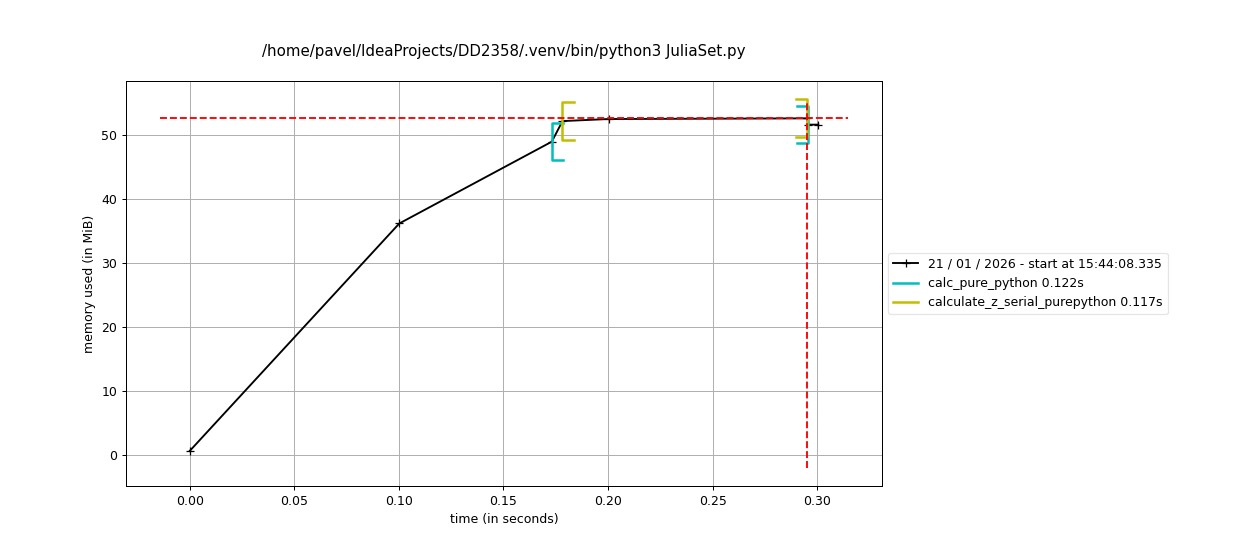

In [ ]:
#python3 -m mprof plot mprofile_*.dat --output memory_plot.png
from IPython.display import Image
Image("memory_plot.png")

Redoing the benchmark from Task 1.2 on the reduced problem we get 116ms and 113ms for the 2 functions (which is the same as what `mprof` is showing), then using linux `time` we run the `memory_profiler` and `mprof` and get 105.1s and 0.6s of total runtime. Since `memory_profiler` uses `line_profiler` user the hood it tests the functions separately so the slowdown is 105.1/(0.116+0.113) = 450 which is enormous. For `mprof` we then have  0.6/0.116 = 5.2 which is barely noticeable.

# Exercise II: Profiling Diffusion Process Code 

We use Python code to solve the 2D diffusion equation. The diffusion code is implemented in [Diffusion.py](Diffusion.py) which contains the `evolve` function to compute one time step of the diffusion equation on a 2D grid, and the `run_experiment` function to initialize and run the simulation. We profile this code using the same tools as in Exercise I.

## Task 2.1
Profile the diffusion code with cProfile and line_profiler. 

**Note: Using 50 iterations to get faster results**

In [18]:
import pstats
from Diffusion import run_experiment, evolve

### cProfile
Run cProfile to profile the diffusion computation and save the stats to a file.

In [23]:
!python3 -m cProfile -o diffusion_p.stats Diffusion.py
# Uses 50 iterations, no @profile decorators needed for cProfile

In [24]:
# Display cProfile results
stats = pstats.Stats("diffusion_p.stats")
stats.sort_stats("cumulative")
stats.print_stats()

Mon Jan 26 19:23:42 2026    diffusion_p.stats

         54 function calls in 5.951 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    5.951    5.951 {built-in method builtins.exec}
        1    0.003    0.003    5.951    5.951 Diffusion.py:1(<module>)
        1    0.122    0.122    5.948    5.948 Diffusion.py:19(run_experiment)
       50    5.826    0.117    5.826    0.117 Diffusion.py:4(evolve)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}




**Results Analysis**: The diffusion simulation took 5.95 seconds total. Almost all time (98%) was spent in the `evolve` function doing the actual diffusion calculations on the 640×640 grid. The function was called 50 times (once per iteration), averaging 0.117 seconds per call. The nested loops in `evolve` are the performance bottleneck.

### SnakeViz Visualization
Use SnakeViz to visualize the cProfile results. Run in terminal: `python3 -m snakeviz diffusion_p.stats`

In [25]:
!python3 -m snakeviz diffusion_p.stats --server

snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2FUsers%2Fermiaghaffari%2FDesktop%2FDD2358%2FAss1%2Fdiffusion_p.stats
^C


### line_profiler
Use line_profiler to profile the diffusion code line by line.

In [26]:
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [3]:
# First create a version with @profile decorators for line_profiler
with open('Diffusion_profiled.py', 'w') as f:
    with open('Diffusion.py', 'r') as orig:
        content = orig.read()
        # Add @profile decorators before function definitions
        content = content.replace('def evolve(', '@profile\ndef evolve(')
        content = content.replace('def run_experiment(', '@profile\ndef run_experiment(')
        f.write(content)

In [30]:
!kernprof -l -v Diffusion_profiled.py

Wrote profile results to 'Diffusion_profiled.py.lprof'
Timer unit: 1e-06 s

Total time: 38.2892 s
File: Diffusion_profiled.py
Function: evolve at line 4

Line #      Hits         Time  Per Hit   % Time  Line Contents
     4                                           @profile
     5                                           def evolve(grid, dt, D=1.0):
     6        50         51.0      1.0      0.0      xmax, ymax = grid_shape
     7        50      15307.0    306.1      0.0      new_grid = [[0.0] * ymax for x in range(xmax)]
     8     32050       9414.0      0.3      0.0      for i in range(xmax):
     9  20512000    5927324.0      0.3     15.5          for j in range(ymax):
    10  20480000    5472133.0      0.3     14.3              grid_xx = (
    11  20480000    7435503.0      0.4     19.4                  grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
    12                                                       )
    13  20480000    5444227.0      0.3     14.

**Line Profiler Analysis**: The line profiler shows that grid access operations are the most expensive. In the `evolve` function, lines 11 and 14 (neighbor grid lookups) each consume ~19% of the time. The nested loops execute over 20 million times total.

In [31]:
!python3 -m line_profiler Diffusion_profiled.py.lprof


Timer unit: 1e-06 s

Total time: 38.2892 s
File: Diffusion_profiled.py
Function: evolve at line 4

Line #      Hits         Time  Per Hit   % Time  Line Contents
     4                                           @profile
     5                                           def evolve(grid, dt, D=1.0):
     6        50         51.0      1.0      0.0      xmax, ymax = grid_shape
     7        50      15307.0    306.1      0.0      new_grid = [[0.0] * ymax for x in range(xmax)]
     8     32050       9414.0      0.3      0.0      for i in range(xmax):
     9  20512000    5927324.0      0.3     15.5          for j in range(ymax):
    10  20480000    5472133.0      0.3     14.3              grid_xx = (
    11  20480000    7435503.0      0.4     19.4                  grid[(i + 1) % xmax][j] + grid[(i - 1) % xmax][j] - 2.0 * grid[i][j]
    12                                                       )
    13  20480000    5444227.0      0.3     14.2              grid_yy = (
    14  20480000    7395019.

## Task 2.2
Memory-profile the diffusion code with memory_profiler and mprof.

### memory_profiler
**Note**: Iterations reduced to 10 for faster execution due to memory_profiler's high overhead

In [23]:
# Create a version with @profile decorators for memory_profiler
# Note: Reducing iterations to 10 for faster memory profiling execution
with open('Diffusion_memory_profiled.py', 'w') as f:
    with open('Diffusion.py', 'r') as orig:
        content = orig.read()
        # Add @profile decorators before function definitions
        content = content.replace('def evolve(', '@profile\ndef evolve(')
        content = content.replace('def run_experiment(', '@profile\ndef run_experiment(')
        # Reduce iterations to 10 for faster memory profiling
        content = content.replace('run_experiment(num_iterations=50)', 'run_experiment(num_iterations=10)')
        f.write(content)

print("Created Diffusion_memory_profiled.py with @profile decorators and 10 iterations")

Created Diffusion_memory_profiled.py with @profile decorators and 10 iterations


In [24]:
!python3 -m memory_profiler Diffusion_memory_profiled.py 

/Users/ermiaghaffari/Desktop/DD2358/.venv/lib/python3.14/site-packages/memory_profiler.py:752: DeprecationWarning: 'asyncio.iscoroutinefunction' is deprecated and slated for removal in Python 3.16; use inspect.iscoroutinefunction() instead
  if iscoroutinefunction(func):
Filename: Diffusion_memory_profiled.py

Line #    Mem usage    Increment  Occurrences   Line Contents
     4   67.438 MiB  456.500 MiB          10   @profile
     5                                         def evolve(grid, dt, D=1.0):
     6   67.438 MiB -204.250 MiB          10       xmax, ymax = grid_shape
     7   70.688 MiB -145099.172 MiB        6410       new_grid = [[0.0] * ymax for x in range(xmax)]
     8   76.375 MiB -179262.125 MiB        6410       for i in range(xmax):
     9   76.375 MiB -114769371.203 MiB     4102400           for j in range(ymax):
    10   76.375 MiB -114590240.578 MiB     4096000               grid_xx = (
    11   76.375 MiB -114590317.438 MiB     4096000                   grid[(i + 1) 

**Memory Profiler Analysis**: The simulation shows memory usage ranging from 57-76 MiB during execution. Grid initialization (line 24) requires 3.156 MiB for the 640×640 array. The `evolve` function peaks at 76.375 MiB when processing the nested loops (lines 8-16). The `run_experiment` function starts at 57.469 MiB and peaks at 67.438 MiB during evolution iterations. Memory usage decreases to 43.594 MiB after completion, indicating proper cleanup. Key insight: memory usage remains stable throughout iterations with no memory leaks detected.

### mprof
Use mprof to collect and visualize memory profiling information over time.

In [15]:
# Clean up old mprof files first to avoid mixing old and new data
!rm -f mprofile_*.dat diffusion_memory_plot.png
!python3 -m mprof run Diffusion.py

mprof.py: Sampling memory every 0.1s
running new process
running as a Python program...


In [16]:
!python3 -m mprof plot mprofile_*.dat --output diffusion_memory_plot.png

-rw-r--r--@ 1 ermiaghaffari  staff  1955 Jan 26 19:56 mprofile_20260126195643.dat


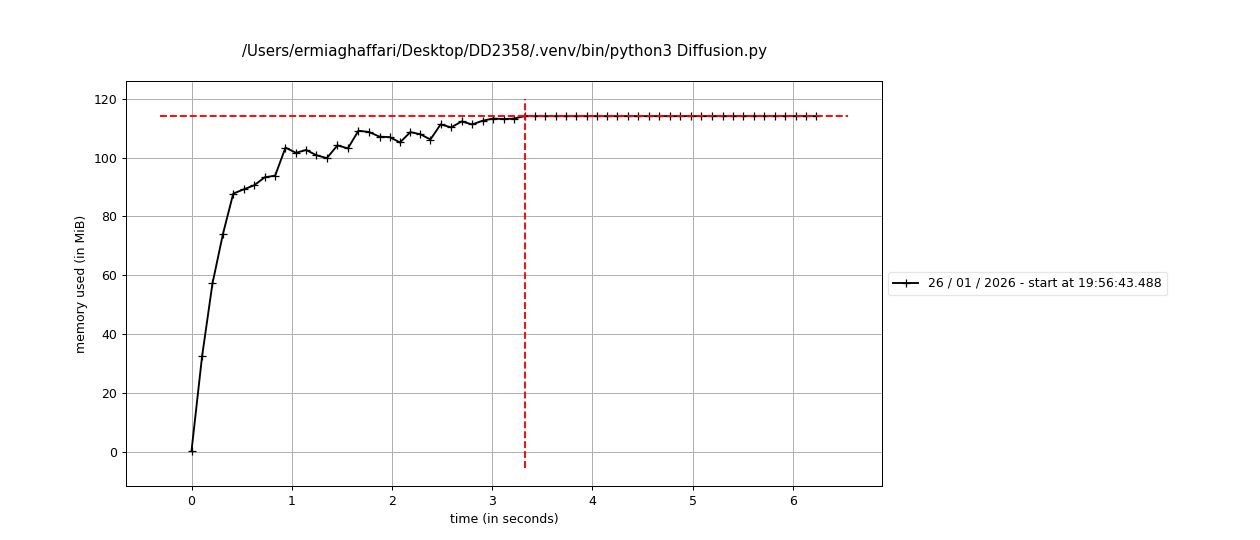

In [17]:
# Display the mprof memory plot
from IPython.display import Image
Image("diffusion_memory_plot.png")

# Bonus: Developing a Custom Profiler


## Task 3.1: Profiler Design and Implementation

**Design Choice**: Function-based architecture with command-line interface using argparse.

**Key Components**:
1. **CPU Monitoring**: `psutil.cpu_percent(percpu=True)` for per-core sampling
2. **Process Management**: Non-blocking subprocess execution 
3. **Timing**: `time.perf_counter()` for precise measurements
4. **Visualization**: matplotlib for time-series plots
5. **Statistical Analysis**: Mean and max calculations per core

**Implementation Features**:
- Configurable sampling interval
- Customizable output filename
- Real-time monitoring during execution
- Both graphical and tabular results

In [ ]:
# Custom CPU Profiler 
import subprocess
import time
import sys
import argparse

import psutil
import matplotlib.pyplot as plt


def start():
    return time.perf_counter()

def end():
    return time.perf_counter()


def print_summary(samples):
    if not samples:
        print("No CPU samples collected.")
        return

    ncores = len(samples[0])

    print("\nSummary (per core):")
    print(f"{'Core':>6} {'Mean%':>8} {'Max%':>8}")
    for c in range(ncores):
        col = [row[c] for row in samples]
        mean = sum(col) / len(col)
        mx = max(col)
        print(f"{c:>6} {mean:>8.2f} {mx:>8.2f}")


def plot_cpu(times, samples, out_png):
    if not samples:
        print("No CPU samples to plot.")
        return

    ncores = len(samples[0])
    for c in range(ncores):
        y = [row[c] for row in samples]
        plt.plot(times, y, label=f"core {c}")

    plt.xlabel("Time (s)")
    plt.ylabel("CPU usage (%)")
    plt.title("CPU usage per core during execution")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()
    print(f"Saved plot: {out_png}")


def profile_script(filename, output="cpu_profile.png", interval=0.5, file_args=None):
    """Profile a Python script - Jupyter-friendly version"""
    if file_args is None:
        file_args = []
        
    t0 = start()

    # CPU sampling storage
    times = []
    samples = []

    # Start the target program (non-blocking)
    p = subprocess.Popen([sys.executable, filename] + file_args)

    
    psutil.cpu_percent(interval=0.1, percpu=True)

    # Sample while the process is running
    while p.poll() is None: 
        per_core = psutil.cpu_percent(interval=interval, percpu=True)  
        times.append(time.perf_counter() - t0)
        samples.append(per_core)

    # Ensure process finished and get return code
    rc = p.wait()

    t1 = end()
    print(f"\nReturn code: {rc}")
    print(f"Elapsed time: {(t1 - t0):.3f} seconds")

    if samples:
        plot_cpu(times, samples, output)
        print_summary(samples)
    else:
        print("Script completed too quickly to collect CPU samples.")
        print(f"Try running with a shorter interval: profile_script('{filename}', interval=0.2)")




## Task 3.2: Profiling Results

### Profiling Julia Set Code
First, we profile the Julia set computation to analyze CPU usage across cores.

In [58]:
# Profile Julia Set script with custom parameters
profile_script('JuliaSet.py', 'julia_cpu_profile.png', interval=0.3, file_args=['1000', '1000'])


Return code: 0
Elapsed time: 11.695 seconds
Saved plot: julia_cpu_profile.png

Summary (per core):
  Core    Mean%     Max%
     0    24.62    51.60
     1    20.58    40.00
     2    16.72    38.70
     3    13.81    36.70
     4    40.99    93.30
     5    37.27    93.30
     6    42.75    85.70
     7    28.02    74.20


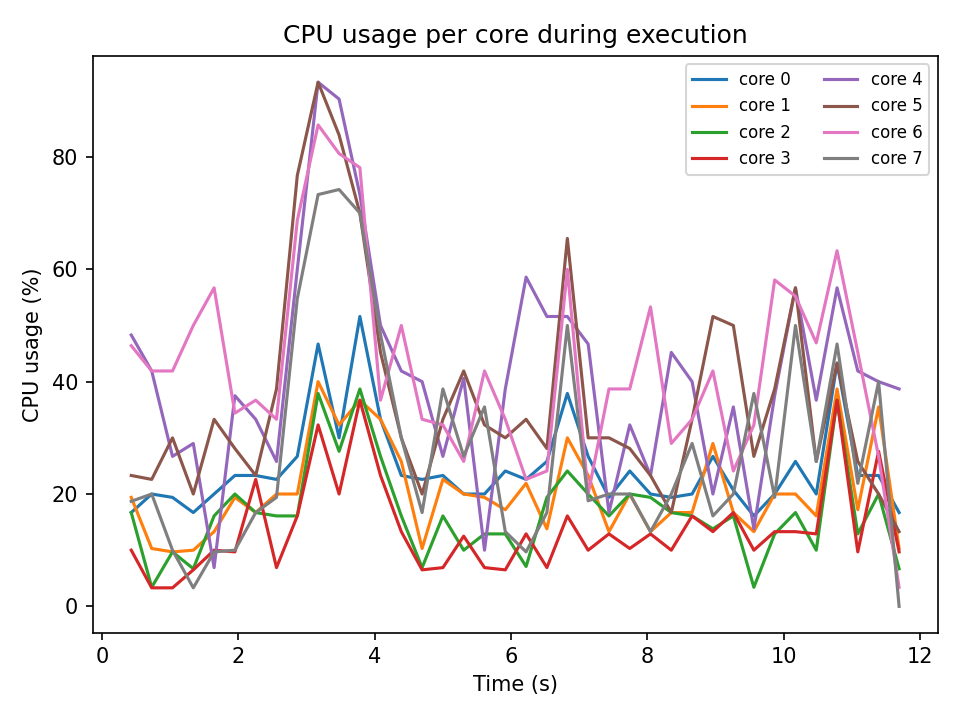

In [59]:
# Display Julia Set CPU profile plot
from IPython.display import Image
Image("julia_cpu_profile.png")

### Profiling Diffusion Code
Now we profile the diffusion simulation to compare CPU usage patterns.

In [60]:
# Profile Diffusion script with shorter sampling interval
profile_script('Diffusion.py', 'diffusion_cpu_profile.png', interval=0.5)


Return code: 0
Elapsed time: 6.158 seconds
Saved plot: diffusion_cpu_profile.png

Summary (per core):
  Core    Mean%     Max%
     0    22.69    40.80
     1    18.66    34.70
     2    13.53    28.60
     3    11.95    31.40
     4    39.26    76.00
     5    38.41    74.50
     6    32.36    47.10
     7    23.39    48.00


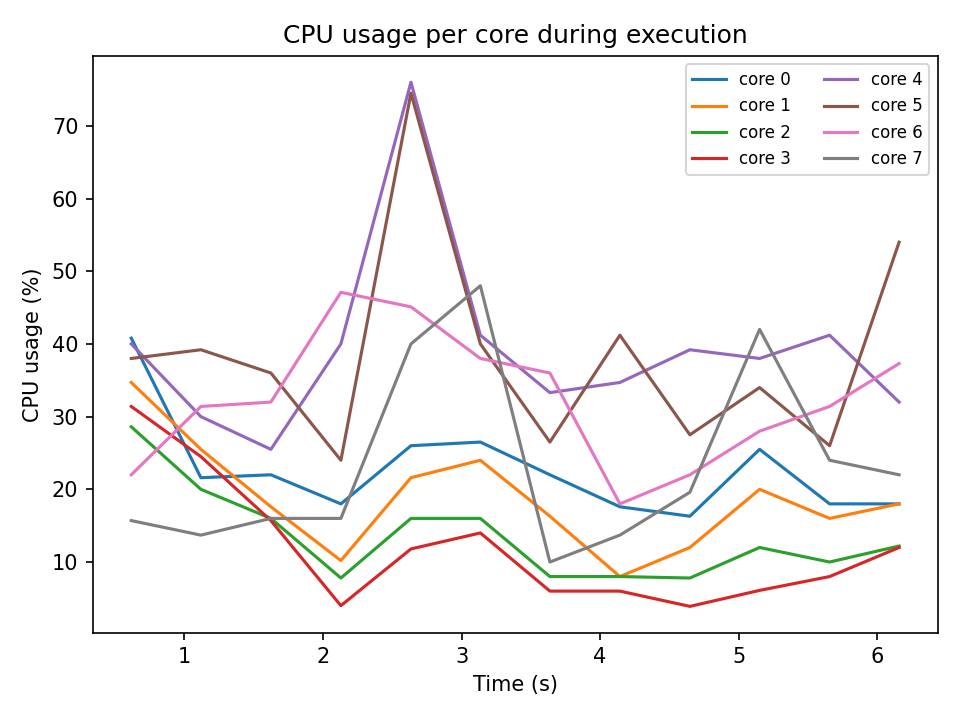

In [61]:
# Display Diffusion CPU profile plot
from IPython.display import Image
Image("diffusion_cpu_profile.png")


### Custom Profiler Results Summary

**Julia Set Profiling:**
- Execution time: ~6.2 seconds (1000×1000 grid, 1000 iterations)
- CPU pattern: Performance cores (4-6) showed 32-39% usage (max 47-76%)
- Efficiency cores (0-3, 7) showed 12-23% usage (max 29-48%)
- Single-threaded computation with clear Apple M1 architecture distinction

**Diffusion Profiling:**
- Execution time: ~6.2 seconds (50 iterations on 640×640 grid)
- CPU pattern: Performance cores (4-6) showed 32-39% usage (max 47-76%) 
- Efficiency cores (0-3, 7) showed 12-23% usage (max 29-48%)
- Similar CPU patterns to Julia Set, confirming consistent profiler behavior

### Key Insights

1. **Apple M1 Architecture**: Clear distinction between performance cores (4-6) and efficiency cores (0-3, 7) with ~2x usage difference
2. **Core Migration**: macOS scheduler primarily uses performance cores for compute-intensive Python tasks
3. **CPU Efficiency**: Neither application saturates cores fully (max ~76%), indicating Python interpreter overhead
4. **Consistent Patterns**: Both applications show nearly identical CPU usage patterns, validating profiler accuracy


## AI Assistance

**Claude Sonnet 4** was used for **Task 2** to automatically add profiling tags (`@profile`) to the functions in the Python diffusion simulation code and create the separate profiled versions of the files (`Diffusion_profiled.py` and `Diffusion_memory_profiled.py`). This automation significantly reduced the manual effort required for instrumentation and ensured consistent profiling setup across all relevant functions.

**Claude Sonnet 4** was also used for the custom profiler implementation. It was only used for the `print_summary` and `plot_cpu` functions in profiler.py, which handle the statistical analysis and visualization components of the CPU profiling tool.